# 08 -- Confidence Intervals & Statistical Significance

Quantifying the patterns from notebook 07 (bias_initial).
Each section feeds one or more of the three research questions.

| # | Question |
|---|----------|
| **Q1** | *Disparity* -- do spell-checkers recognise Western-origin names at systematically higher rates? |
| **Q2** | *Mechanism* -- how much of the gap is script-level vs lexical within a shared writing system? |
| **Q3** | *Correction skew* -- do suggestions for flagged names favour Western-origin alternatives? |

**Conditions analysed**

| Condition | Column | Notes |
|-----------|--------|-------|
| Hunspell B |  | Latin transliteration |
| SymSpell B |  | Latin transliteration |
| LT-auto A |  | Original script; LanguageTool uses language detection |
| LT-auto B |  | Latin transliteration |

Hunspell A and SymSpell A return 0% for all non-Latin scripts -- excluded (see next cell).


In [1]:
import json
import sqlite3
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import (
    proportion_confint,
    proportions_ztest,
    proportion_effectsize,
)
from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load from SQLite ──────────────────────────────────────────────────────────
con = sqlite3.connect('../data/full_results2.db')
df_raw = pd.read_sql('SELECT * FROM names', con)
con.close()
print(f'Raw rows loaded: {len(df_raw):,}')

# ── Cleaning (replicates notebook 07 (bias_initial) filter) ──────────────────────────────────
# Keep single-word names made up of Unicode letters, combining marks,
# hyphens, and apostrophes only. This removes digits, punctuation noise,
# and multi-word entries that would confound the per-name comparisons.
_EXTRA = {'-', "'"}

def _valid(name):
    if not isinstance(name, str) or ' ' in name or len(name) < 2:
        return False
    return all(
        unicodedata.category(ch)[0] in ('L', 'M') or ch in _EXTRA
        for ch in name
    )

df = df_raw[df_raw['name'].apply(_valid)].copy()
df['name_length'] = df['name'].str.len()

# Short ethnicolr labels: 'GreaterEuropean,WestEuropean,French' -> 'French'
df['eth_short'] = df['ethnicolr_race'].str.split(',').str[-1].fillna('Unknown')

print(f'After cleaning: {len(df):,} names ({len(df)/len(df_raw)*100:.1f}% retained)')
print(f'\nScript families (top 12):')
print(df['name_script'].value_counts().head(12).to_string())
print(f'\nOverall Condition B name recognition rates:')
for col, label in [('hunspell_latin_known','Hunspell'),
                   ('symspell_latin_known','SymSpell'),
                   ('lt_auto_latin_known', 'LT-auto ')]:
    print(f'  {label}: {df[col].mean()*100:.2f}%')

Raw rows loaded: 727,352
After cleaning: 571,028 names (78.5% retained)

Script families (top 12):
name_script
Latin         463454
Arabic         32247
Cyrillic       26636
CJK            20290
Hangul         12324
Hebrew          4198
Greek           3243
Bengali         2824
Georgian        2098
Ethiopic         671
Hiragana         647
Devanagari       598

Overall Condition B name recognition rates:
  Hunspell: 4.90%
  SymSpell: 4.16%
  LT-auto : 13.28%


In [3]:
# ── Shared constants ──────────────────────────────────────────────────────────────

# All four meaningful conditions
FOCUS_CONDS = [
    ('hunspell_latin_known', 'Hunspell B'),
    ('symspell_latin_known', 'SymSpell B'),
    ('lt_auto_orig_known',   'LT-auto A'),
    ('lt_auto_latin_known',  'LT-auto B'),
]

# Condition-B only -- used for ethnicolr analyses where LT-auto A is redundant
# (for Latin-script names anyascii changes nothing, so A == B)
COND_B = [
    ('hunspell_latin_known', 'Hunspell B'),
    ('symspell_latin_known', 'SymSpell B'),
    ('lt_auto_latin_known',  'LT-auto B'),
]

# LT-auto columns used explicitly in the McNemar (paired) analysis
LT_ORIG_COL  = 'lt_auto_orig_known'
LT_LATIN_COL = 'lt_auto_latin_known'

# Script families with >= 500 names (smaller groups give unreliable estimates)
MAJOR_SCRIPTS = [
    'Latin', 'Arabic', 'Cyrillic', 'CJK', 'Hangul',
    'Hebrew', 'Bengali', 'Greek', 'Georgian', 'Ethiopic',
]

# Ethnicolr categories considered Western-adjacent
WESTERN_ETH = {'British', 'Germanic', 'Nordic', 'French', 'Italian'}

# Derived subsets
df_major      = df[df['name_script'].isin(MAJOR_SCRIPTS)].copy()
df_non_latin  = df[df['name_script'] != 'Latin'].copy()
df_latin_only = df[df['name_script'] == 'Latin'].copy()

# Western subset
df_western_eth = df[df['ethnicolr_race'].str.split(',').str[-1].isin(WESTERN_ETH)].copy()

print(f'Major-script subset:   {len(df_major):,} names')
print(f'Non-Latin subset:      {len(df_non_latin):,} names')
print(f'Latin-only subset:     {len(df_latin_only):,} names')
print(f'Western origin subset: {len(df_western_eth):,} names')


Major-script subset:   567,985 names
Non-Latin subset:      107,574 names
Latin-only subset:     463,454 names
Western origin subset: 194,611 names


In [4]:
# ── Why Hunspell A and SymSpell A are excluded ─────────────────────────────────
# Hunspell and SymSpell match names against an English word-list stored in
# ASCII / Latin-1.  They cannot parse non-Latin Unicode characters at all.
# Their Condition A (original-script) recognition rate is therefore 0 % for
# every non-Latin script family -- not a finding, just a hard technical limit.
# We confirm this here and exclude both conditions from all subsequent tests.

print('Condition A recognition -- non-Latin-script names (major script families only)')
print('Hunspell and SymSpell cannot process non-Latin characters.\n')

for col, label in [('hunspell_orig_known', 'Hunspell A'),
                    ('symspell_orig_known', 'SymSpell A')]:
    sub = df_non_latin[df_non_latin['name_script'].isin(MAJOR_SCRIPTS)]
    tbl = sub.groupby('name_script')[col].agg(['sum', 'count'])
    tbl['rate_%'] = (tbl['sum'] / tbl['count'] * 100).round(2)
    tbl.columns   = ['n_known', 'n_total', 'rate_%']
    print(f'--- {label} ---')
    print(tbl[['n_total', 'n_known', 'rate_%']].to_string())
    print()

print('Both tools return 0 % for every non-Latin script.')
print('Hunspell A and SymSpell A are excluded from all further analysis.')


Condition A recognition -- non-Latin-script names (major script families only)
Hunspell and SymSpell cannot process non-Latin characters.

--- Hunspell A ---
             n_total  n_known  rate_%
name_script                          
Arabic         32247        0  0.0000
Bengali         2824        0  0.0000
CJK            20290        0  0.0000
Cyrillic       26636        0  0.0000
Ethiopic         671        0  0.0000
Georgian        2098        0  0.0000
Greek           3243        0  0.0000
Hangul         12324        0  0.0000
Hebrew          4198        0  0.0000

--- SymSpell A ---
             n_total  n_known  rate_%
name_script                          
Arabic         32247        0  0.0000
Bengali         2824        0  0.0000
CJK            20290        0  0.0000
Cyrillic       26636        0  0.0000
Ethiopic         671        0  0.0000
Georgian        2098        0  0.0000
Greek           3243        0  0.0000
Hangul         12324        0  0.0000
Hebrew          4198    

---
## Note: statistics at this sample size

~570,000 names means every p-value is effectively zero -- a 0.01 pp difference is
"significant". Significance tests confirm gaps are real; they say nothing about size.

Use this order of priority when writing up:
1. **Cohen's h / Odds Ratio** -- magnitude of the gap, scale-independent
2. **Confidence intervals** -- precision of each rate estimate
3. **p-values** -- mention briefly to confirm not noise

Patterns consistent across Hunspell, SymSpell, and LT-auto are the strongest evidence
of a systemic issue rather than one tool's quirk.


---
## Q1: Disparity -- Wilson Confidence Intervals

95% Wilson CIs give a precise range for each group's true recognition rate.
At this sample size the intervals are very narrow -- the rates are well-estimated.
What matters is the *gap between groups*, not the width of any single interval.

**Script analysis** (all four conditions): how much does script family alone predict recognition?

**Origin analysis** (Condition B, Latin-script names only): once all names are romanised,
any remaining gap between e.g. British and EastAsian names is lexical, not script-related.


In [5]:
def recognition_table(data, group_col, known_col, min_n=100):
    """
    For each group: n, n recognised, recognition %, 95% Wilson CI.
    Groups with < min_n names are excluded.
    Returns a DataFrame sorted by recognition rate descending.
    """
    rows = []
    for group, grp in data.groupby(group_col):
        n = len(grp)
        if n < min_n:
            continue
        k = int(grp[known_col].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        rows.append({
            'group':    group,
            'n':        n,
            'known':    k,
            'rate_%':   round(k / n * 100, 2),
            'CI_low':   round(lo * 100, 2),
            'CI_high':  round(hi * 100, 2),
            'CI_width': round((hi - lo) * 100, 3),
        })
    return (
        pd.DataFrame(rows)
        .sort_values('rate_%', ascending=False)
        .reset_index(drop=True)
    )


# Per-script CIs for all four meaningful conditions
print('Q1: Recognition rates by script family')
print('95% Wilson confidence intervals\n')

for col, label in FOCUS_CONDS:
    tbl = recognition_table(df_major, 'name_script', col)
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()


Q1: Recognition rates by script family
95% Wilson confidence intervals

-- Hunspell B --
   group      n  known  rate_%  CI_low  CI_high  CI_width
   Greek   3243    408 12.5800 11.4800  13.7700    2.2830
Cyrillic  26636   1473  5.5300  5.2600   5.8100    0.5490
   Latin 463454  25189  5.4400  5.3700   5.5000    0.1310
Georgian   2098    112  5.3400  4.4600   6.3800    1.9290
 Bengali   2824    149  5.2800  4.5100   6.1600    1.6520
Ethiopic    671     16  2.3800  1.4700   3.8400    2.3650
  Arabic  32247    423  1.3100  1.1900   1.4400    0.2490
  Hebrew   4198     26  0.6200  0.4200   0.9100    0.4830
  Hangul  12324      3  0.0200  0.0100   0.0700    0.0630
     CJK  20290      0  0.0000  0.0000   0.0200    0.0190

-- SymSpell B --
   group      n  known  rate_%  CI_low  CI_high  CI_width
   Greek   3243    394 12.1500 11.0700  13.3200    2.2490
Georgian   2098    197  9.3900  8.2100  10.7100    2.4980
 Bengali   2824    192  6.8000  5.9300   7.7900    1.8590
Cyrillic  26636   1360 

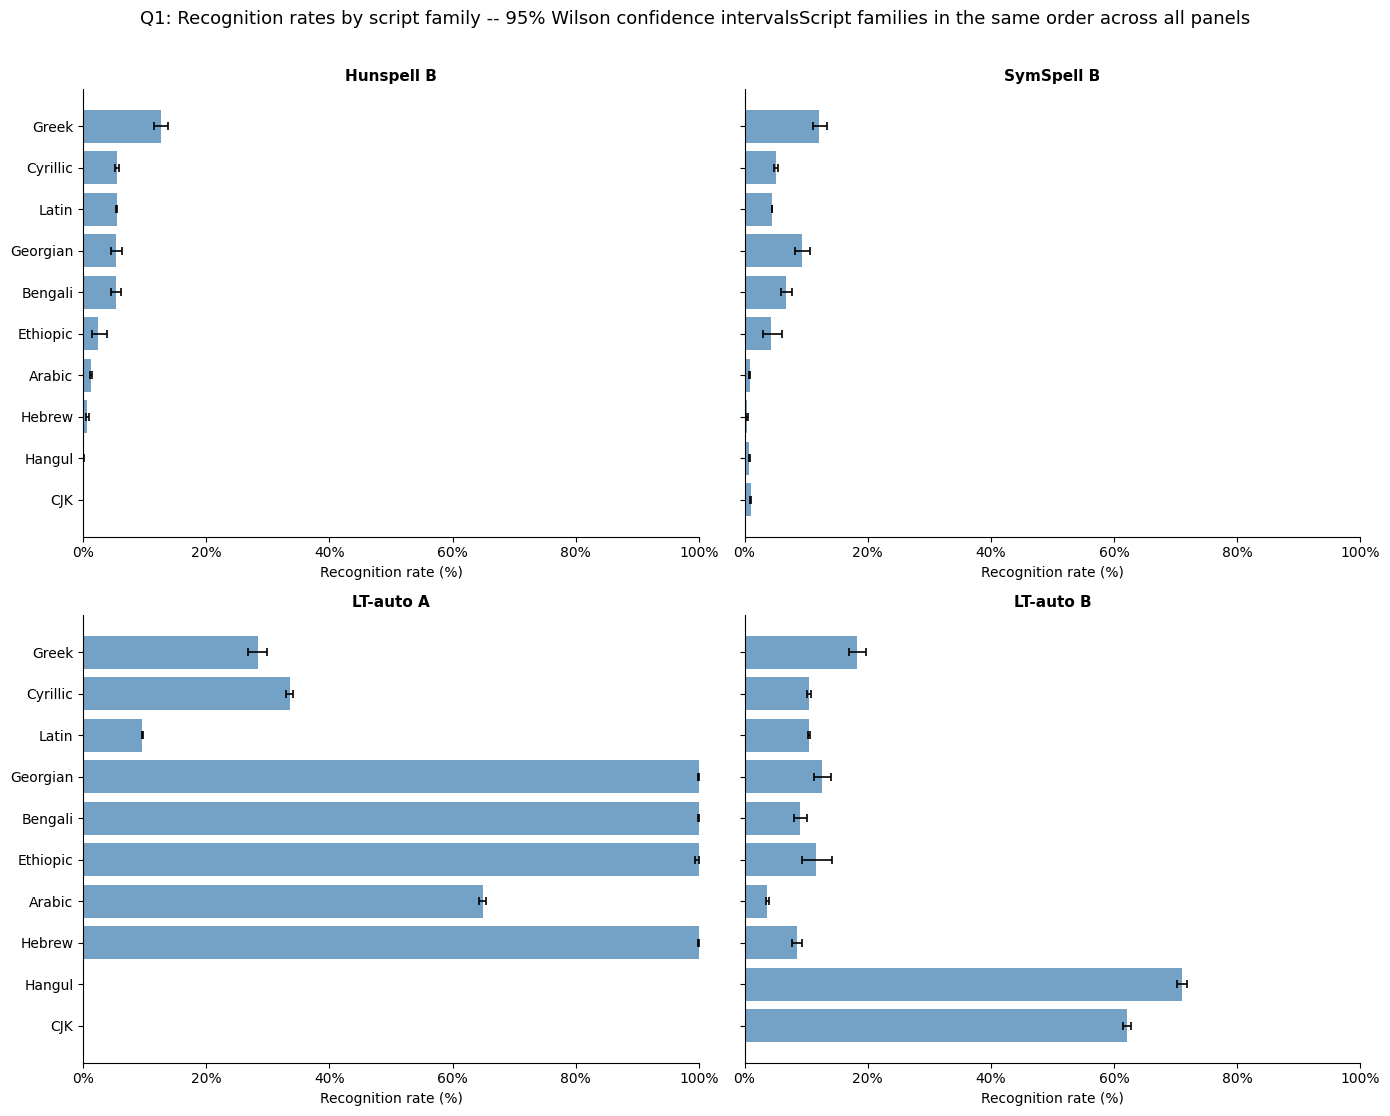

Consistent patterns = systemic property of English spell-checkers.
Tool-specific outliers (e.g. Arabic/Hebrew under LT-auto A) reflect design differences.


In [6]:
# Q1: Recognition rates by script -- all four conditions in a 2x2 grid
# Same y-axis order across panels so patterns are easy to compare.

ref_order = (
    recognition_table(df_major, "name_script", "hunspell_latin_known")
    .sort_values("rate_%", ascending=True)["group"].tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharey=True)
axes = axes.flatten()

for ax, (col, label) in zip(axes, FOCUS_CONDS):
    ci_tbl = recognition_table(df_major, "name_script", col)
    ci_tbl = ci_tbl.set_index("group").reindex(ref_order).reset_index()
    ax.barh(
        ci_tbl["group"], ci_tbl["rate_%"],
        xerr=[ci_tbl["rate_%"] - ci_tbl["CI_low"],
              ci_tbl["CI_high"] - ci_tbl["rate_%"]],
        color="steelblue", alpha=0.75, capsize=3,
        error_kw={"elinewidth": 1.2, "capthick": 1.2},
    )
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Recognition rate (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 100)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle(
    "Q1: Recognition rates by script family -- 95% Wilson confidence intervals"
    "Script families in the same order across all panels",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

print("Consistent patterns = systemic property of English spell-checkers.")
print("Tool-specific outliers (e.g. Arabic/Hebrew under LT-auto A) reflect design differences.")


Q1: Recognition rates by predicted origin category -- Condition B
LATIN-SCRIPT NAMES ONLY
95% Wilson confidence intervals
-- Hunspell B --
             group     n  known  rate_%  CI_low  CI_high  CI_width
            French  5790    594 10.2600  9.5000  11.0700    1.5630
          Germanic 10255    889  8.6700  8.1400   9.2300    1.0890
           British 82959   6681  8.0500  7.8700   8.2400    0.3700
            Nordic 49333   3701  7.5000  7.2700   7.7400    0.4650
         EastAsian 96972   6075  6.2600  6.1100   6.4200    0.3050
           Italian 18584   1132  6.0900  5.7600   6.4400    0.6880
      EastEuropean 13443    787  5.8500  5.4700   6.2600    0.7940
          Hispanic 15970    883  5.5300  5.1900   5.8900    0.7090
            Muslim 37143   1245  3.3500  3.1700   3.5400    0.3660
          Japanese 25996    814  3.1300  2.9300   3.3500    0.4240
            Jewish 17342    533  3.0700  2.8300   3.3400    0.5140
IndianSubContinent 66404   1604  2.4200  2.3000   2.5400 

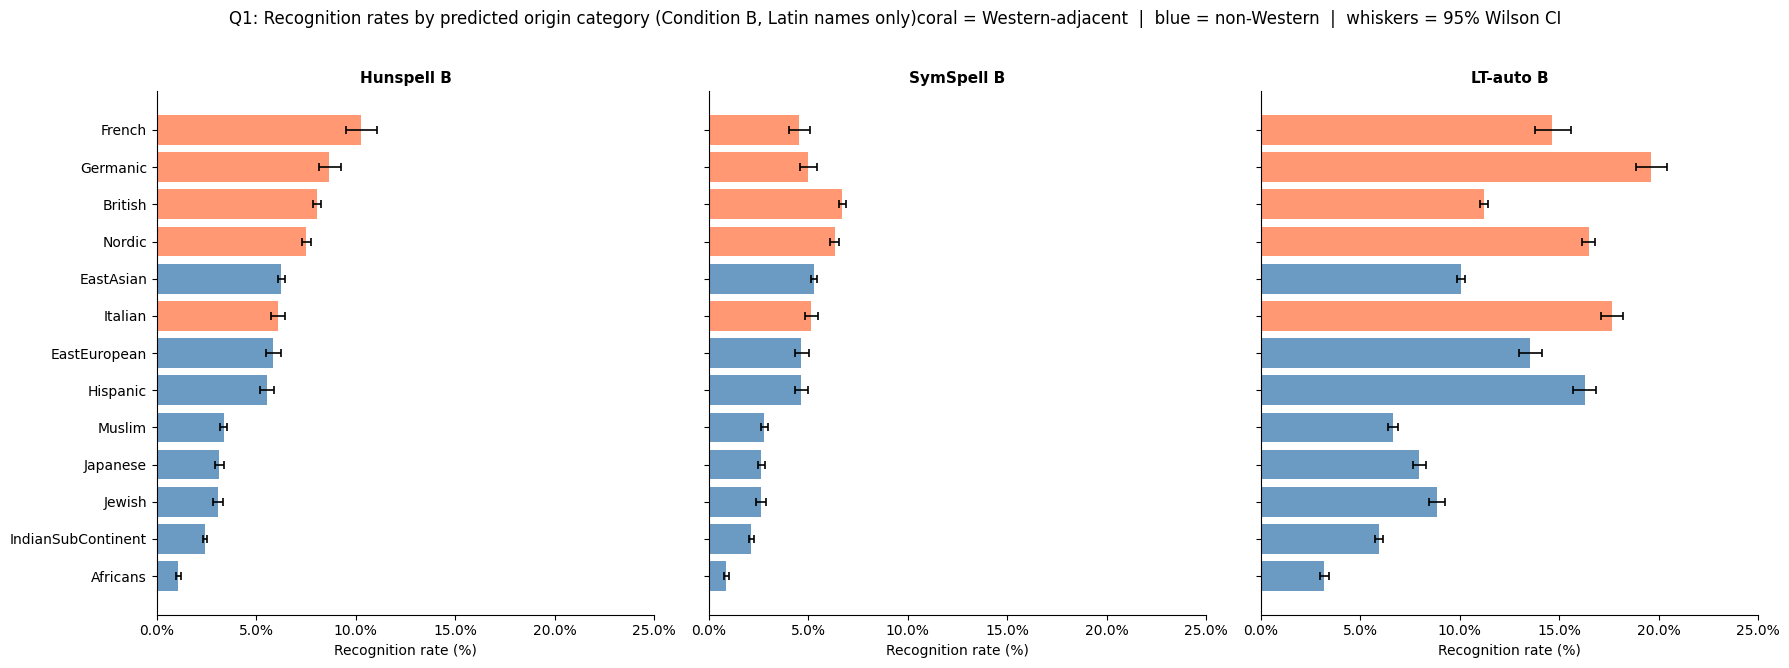

In [7]:
# Q1: Recognition rates by origin -- Condition B, Latin-script names only.
# Restricting to Latin names isolates lexical bias from script effects.
# LT-auto A omitted: for Latin names A==B (anyascii leaves Latin unchanged).

print("Q1: Recognition rates by predicted origin category -- Condition B")
print("LATIN-SCRIPT NAMES ONLY")
print("95% Wilson confidence intervals")

eth_data_plot = df_latin_only[df_latin_only["eth_short"] != "Unknown"]

for col, label in COND_B:
    tbl = recognition_table(eth_data_plot, "eth_short", col)
    print(f"-- {label} --")
    print(tbl.to_string(index=False))
    print()

# Side-by-side 3-panel; consistent y-axis order across panels
ref_eth_order = (
    recognition_table(eth_data_plot, "eth_short", "hunspell_latin_known")
    .sort_values("rate_%", ascending=True)["group"].tolist()
)

fig, axes = plt.subplots(1, 3,
                          figsize=(18, max(5, len(ref_eth_order) * 0.5)),
                          sharey=True)

for ax, (col, label) in zip(axes, COND_B):
    tbl = (
        recognition_table(eth_data_plot, "eth_short", col)
        .set_index("group").reindex(ref_eth_order).reset_index()
    )
    colors = ["coral" if g in WESTERN_ETH else "steelblue" for g in tbl["group"]]
    ax.barh(
        tbl["group"], tbl["rate_%"],
        xerr=[tbl["rate_%"] - tbl["CI_low"],
              tbl["CI_high"] - tbl["rate_%"]],
        color=colors, alpha=0.80, capsize=3,
        error_kw={"elinewidth": 1.2, "capthick": 1.2},
    )
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Recognition rate (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 25)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle(
    "Q1: Recognition rates by predicted origin category (Condition B, Latin names only)"
    "coral = Western-adjacent  |  blue = non-Western  |  whiskers = 95% Wilson CI",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


---
## Q2: Mechanism -- McNemar's Test (LT-auto A vs B only)

Each name was tested twice: original script (A) and Latin transliteration (B).
McNemar's test checks whether the A-to-B shift is systematic:
- **b** = recognised in A but not B
- **c** = recognised in B but not A

If c >> b, transliteration fixed a script barrier.

**Why LT-auto only:** Hunspell/SymSpell return 0% for all non-Latin scripts in A,
forcing b = 0 by construction -- the result would be trivially one-sided.
LT-auto has genuine discordant pairs (Arabic, Hebrew partially recognised in A via
language detection; CJK/Hangul near-zero in A).

Comparing the per-script delta_pp values answers Q2 directly: large delta = script was
the barrier; small delta = something else (detection or dictionary) already helped in A.


In [8]:
def mcnemar_result(data, orig_col, lat_col):
    """
    McNemar's test comparing Condition A vs Condition B (paired binary outcomes).

    2x2 layout:
               | B known | B unknown
    A known    |  both   |  a_only (b)
    A unknown  |  b_only (c) | neither

    Null hypothesis: b == c (no systematic shift).
    c >> b means transliteration helps recognition.
    """
    a = data[orig_col].astype(bool)
    b = data[lat_col].astype(bool)

    both   = int(( a &  b).sum())
    a_only = int(( a & ~b).sum())  # b in the formula
    b_only = int((~a &  b).sum())  # c in the formula
    neith  = int((~a & ~b).sum())

    result = _mcnemar([[both, a_only], [b_only, neith]], exact=False, correction=True)

    return {
        'n':           len(data),
        'rate_A_%':    round(a.mean() * 100, 2),
        'rate_B_%':    round(b.mean() * 100, 2),
        'delta_pp':    round((b.mean() - a.mean()) * 100, 2),
        'b (A-only)':  a_only,
        'c (B-only)':  b_only,
        'chi2':        round(result.statistic, 2),
        'p':           result.pvalue,
    }


print("Q2: McNemar's test -- LT-auto, Condition A vs Condition B")
print('Non-Latin-script names only')
print('(Hunspell/SymSpell A = 0 % for all non-Latin scripts -- excluded)')
print('=' * 70)

rows = []
r = mcnemar_result(df_non_latin, LT_ORIG_COL, LT_LATIN_COL)
r['scope'] = 'ALL non-Latin'
rows.append(r)

for script in [s for s in MAJOR_SCRIPTS if s != 'Latin']:
    sub = df_non_latin[df_non_latin['name_script'] == script]
    if len(sub) < 100:
        continue
    r = mcnemar_result(sub, LT_ORIG_COL, LT_LATIN_COL)
    r['scope'] = script
    rows.append(r)

tbl = pd.DataFrame(rows)[[
    'scope', 'n', 'rate_A_%', 'rate_B_%', 'delta_pp',
    'b (A-only)', 'c (B-only)', 'chi2', 'p'
]]
tbl['p'] = tbl['p'].apply(lambda v: f'{v:.2e}')

print()
print(tbl.to_string(index=False))

print()
print('Interpretation:')
print('  c >> b  : transliteration fixed a script barrier (e.g. CJK, Hangul)')
print('  b ~= c  : some Condition A recognition exists (e.g. Arabic via language detection)')
print('  delta_pp: practical magnitude; p confirms the shift is not chance.')


Q2: McNemar's test -- LT-auto, Condition A vs Condition B
Non-Latin-script names only
(Hunspell/SymSpell A = 0 % for all non-Latin scripts -- excluded)

        scope      n  rate_A_%  rate_B_%  delta_pp  b (A-only)  c (B-only)       chi2         p
ALL non-Latin 107574   39.3200   25.3700  -13.9500       38383       23378  3645.0200  0.00e+00
       Arabic  32247   64.8900    3.7300  -61.1600       20018         297 19142.4300  0.00e+00
     Cyrillic  26636   33.5600   10.5000  -23.0600        7272        1130  4488.4400  0.00e+00
          CJK  20290    0.0000   62.1600   62.1600           0       12612 12610.0000  0.00e+00
       Hangul  12324    0.0000   71.1100   71.1100           0        8764  8762.0000  0.00e+00
       Hebrew   4198  100.0000    8.5000  -91.5000        3841           0  3839.0000  0.00e+00
      Bengali   2824  100.0000    9.0700  -90.9300        2568           0  2566.0000  0.00e+00
        Greek   3243   28.3400   18.2900  -10.0500         747         421    9

---
## Q1 (continued): Chi-squared and Pairwise Comparisons

**Chi-squared** tests whether recognition is independent of group membership across all groups.
**Pairwise z-tests** compare each group to a reference (Latin for scripts; British for origins).
Benjamini-Hochberg FDR correction is applied. At this n, essentially all comparisons
will be significant -- focus on effect sizes in the next section.


In [9]:
print('Q1: Chi-squared test of independence')
print('H0: recognition rate is independent of group membership')
print()

eth_sub = df_latin_only[df_latin_only['eth_short'] != 'Unknown']

print('By script family (all four conditions):')
for col, label in FOCUS_CONDS:
    ct = pd.crosstab(df_major['name_script'], df_major[col].astype(int))
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f'  {label:<14}  chi2({dof}) = {chi2:>12,.1f},  p = {p:.2e}')

print()
print('By origin category -- Condition B, Latin-script names only:')
for col, label in COND_B:
    ct2 = pd.crosstab(eth_sub['eth_short'], eth_sub[col].astype(int))
    chi2b, pb, dof2, _ = chi2_contingency(ct2)
    print(f'  {label:<14}  chi2({dof2}) = {chi2b:>12,.1f},  p = {pb:.2e}')

print()
print('All p << 0.001: recognition rates are not uniform across groups.')
print('Proceed to pairwise tests to identify which groups drive this.')


Q1: Chi-squared test of independence
H0: recognition rate is independent of group membership

By script family (all four conditions):
  Hunspell B      chi2(9) =      3,462.8,  p = 0.00e+00
  SymSpell B      chi2(9) =      2,821.2,  p = 0.00e+00
  LT-auto A       chi2(9) =    142,258.8,  p = 0.00e+00
  LT-auto B       chi2(9) =     83,971.9,  p = 0.00e+00

By origin category -- Condition B, Latin-script names only:
  Hunspell B      chi2(12) =      4,944.9,  p = 0.00e+00
  SymSpell B      chi2(12) =      3,687.2,  p = 0.00e+00
  LT-auto B       chi2(12) =      8,294.8,  p = 0.00e+00

All p << 0.001: recognition rates are not uniform across groups.
Proceed to pairwise tests to identify which groups drive this.


In [10]:
def pairwise_vs_ref(data, group_col, known_col, ref_group, min_n=100):
    """
    Two-proportion z-test for every group vs ref_group.
    Returns a DataFrame with raw and Benjamini-Hochberg FDR-corrected p-values.
    """
    ref   = data[data[group_col] == ref_group]
    k_ref = int(ref[known_col].sum())
    n_ref = len(ref)
    p_ref = k_ref / n_ref

    rows = []
    for name, grp in data.groupby(group_col):
        if name == ref_group or len(grp) < min_n:
            continue
        k, n = int(grp[known_col].sum()), len(grp)
        z, p_raw = proportions_ztest([k, k_ref], [n, n_ref])
        rows.append({
            'group':   name,
            'n':       n,
            f'{ref_group}_%': round(p_ref * 100, 2),
            'group_%': round(k / n * 100, 2),
            'diff_pp': round((k / n - p_ref) * 100, 2),
            'z':       round(z, 2),
            'p_raw':   p_raw,
        })

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    _, p_adj, _, _ = multipletests(out['p_raw'], method='fdr_bh')
    out['p_adj (BH)'] = p_adj
    out['sig'] = out['p_adj (BH)'].apply(
        lambda v: '***' if v < 0.001 else ('**' if v < 0.01 else ('*' if v < 0.05 else 'ns'))
    )
    return out.sort_values('diff_pp').reset_index(drop=True)


print('Q1: Pairwise comparisons -- each script vs Latin (reference group)')
print('FDR correction: Benjamini-Hochberg | neg diff_pp = lower than Latin\n')

for col, label in FOCUS_CONDS:
    pw = pairwise_vs_ref(df_major, 'name_script', col, 'Latin')
    pw['p_adj (BH)'] = pw['p_adj (BH)'].apply(lambda v: f'{v:.2e}')
    print(f'-- {label} --')
    print(pw.to_string(index=False))
    print()


Q1: Pairwise comparisons -- each script vs Latin (reference group)
FDR correction: Benjamini-Hochberg | neg diff_pp = lower than Latin

-- Hunspell B --
   group     n  Latin_%  group_%  diff_pp        z  p_raw p_adj (BH) sig
     CJK 20290   5.4400   0.0000  -5.4400 -34.1100 0.0000  5.07e-254 ***
  Hangul 12324   5.4400   0.0200  -5.4100 -26.4700 0.0000  5.83e-154 ***
  Hebrew  4198   5.4400   0.6200  -4.8200 -13.7500 0.0000   8.82e-43 ***
  Arabic 32247   5.4400   1.3100  -4.1200 -32.3400 0.0000  7.61e-229 ***
Ethiopic   671   5.4400   2.3800  -3.0500  -3.4800 0.0005   7.40e-04 ***
 Bengali  2824   5.4400   5.2800  -0.1600  -0.3700 0.7104   7.99e-01  ns
Georgian  2098   5.4400   5.3400  -0.1000  -0.1900 0.8455   8.46e-01  ns
Cyrillic 26636   5.4400   5.5300   0.1000   0.6700 0.5060   6.51e-01  ns
   Greek  3243   5.4400  12.5800   7.1500  17.8100 0.0000   1.31e-70 ***

-- SymSpell B --
   group     n  Latin_%  group_%  diff_pp        z  p_raw p_adj (BH) sig
  Hebrew  4198   4.4700   

In [11]:
# Q1: Pairwise origin comparisons -- Condition B, Latin-script names only
print('Q1: Pairwise comparisons -- each origin category vs British (reference group)')
print('LATIN-SCRIPT NAMES ONLY | Condition B | FDR: Benjamini-Hochberg')
print('neg diff_pp = lower recognition rate than British-origin names\n')

eth_counts = df_latin_only['eth_short'].value_counts()
valid_eth  = eth_counts[eth_counts >= 100].index
eth_data   = df_latin_only[df_latin_only['eth_short'].isin(valid_eth)]

for col, label in COND_B:
    pw = pairwise_vs_ref(eth_data, 'eth_short', col, 'British')
    if not pw.empty:
        pw['p_adj (BH)'] = pw['p_adj (BH)'].apply(lambda v: f'{v:.2e}')
    print(f'-- {label} --')
    print(pw.to_string(index=False))
    print()


Q1: Pairwise comparisons -- each origin category vs British (reference group)
LATIN-SCRIPT NAMES ONLY | Condition B | FDR: Benjamini-Hochberg
neg diff_pp = lower recognition rate than British-origin names

-- Hunspell B --
             group     n  British_%  group_%  diff_pp        z  p_raw p_adj (BH) sig
          Africans 23263     8.0500   1.0800  -6.9700 -38.0600 0.0000   0.00e+00 ***
IndianSubContinent 66404     8.0500   2.4200  -5.6400 -47.3000 0.0000   0.00e+00 ***
            Jewish 17342     8.0500   3.0700  -4.9800 -23.0800 0.0000  1.59e-117 ***
          Japanese 25996     8.0500   3.1300  -4.9200 -27.3600 0.0000  2.41e-164 ***
            Muslim 37143     8.0500   3.3500  -4.7000 -30.3300 0.0000  1.73e-201 ***
          Hispanic 15970     8.0500   5.5300  -2.5200 -10.9900 0.0000   7.08e-28 ***
      EastEuropean 13443     8.0500   5.8500  -2.2000  -8.8500 0.0000   1.19e-18 ***
           Italian 18584     8.0500   6.0900  -1.9600  -9.0700 0.0000   1.75e-19 ***
         Eas

---
## Q1 (continued): Cohen's h Effect Size

Cohen's h measures effect size for proportions, independent of sample size.

| |h| | Label |
|----|-------|
| < 0.20 | Small |
| 0.20 -- 0.50 | Medium |
| 0.50 -- 0.80 | Large |
| > 0.80 | Very large |

A very large effect means the gap is practically meaningful, not just statistically detectable.


In [12]:
def cohens_h_table(data, group_col, known_col, ref_group, min_n=100):
    """
    Cohen's h for every group vs ref_group.
    Negative h = group has lower recognition than the reference.
    """
    p_ref = data[data[group_col] == ref_group][known_col].mean()
    rows  = []
    for name, grp in data.groupby(group_col):
        if len(grp) < min_n:
            continue
        p_grp = grp[known_col].mean()
        h = proportion_effectsize(p_grp, p_ref)
        mag = (
            'Very large' if abs(h) > 0.80
            else 'Large'  if abs(h) > 0.50
            else 'Medium' if abs(h) > 0.20
            else 'Small'
        )
        rows.append({
            'group':     name,
            'n':         len(grp),
            'rate_%':    round(p_grp * 100, 2),
            f'ref ({ref_group})_%': round(p_ref * 100, 2),
            'Cohen_h':   round(h, 4),
            'magnitude': mag,
        })
    return pd.DataFrame(rows).sort_values('Cohen_h').reset_index(drop=True)


# Script-level: all four conditions
print("Q1: Cohen's h -- each script vs Latin | neg = lower recognition\n")
for col, label in FOCUS_CONDS:
    tbl = cohens_h_table(df_major, 'name_script', col, 'Latin')
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()

# Ethnicolr-level: Condition B only
print("Q1: Cohen's h -- each origin category vs British | Condition B | Latin names only\n")
for col, label in COND_B:
    tbl = cohens_h_table(
        df_latin_only[df_latin_only['eth_short'] != 'Unknown'],
        'eth_short', col, 'British'
    )
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()


Q1: Cohen's h -- each script vs Latin | neg = lower recognition

-- Hunspell B --
   group      n  rate_%  ref (Latin)_%  Cohen_h magnitude
     CJK  20290  0.0000         5.4400  -0.4706    Medium
  Hangul  12324  0.0200         5.4400  -0.4394    Medium
  Hebrew   4198  0.6200         5.4400  -0.3130    Medium
  Arabic  32247  1.3100         5.4400  -0.2410    Medium
Ethiopic    671  2.3800         5.4400  -0.1605     Small
 Bengali   2824  5.2800         5.4400  -0.0071     Small
Georgian   2098  5.3400         5.4400  -0.0043     Small
   Latin 463454  5.4400         5.4400   0.0000     Small
Cyrillic  26636  5.5300         5.4400   0.0042     Small
   Greek   3243 12.5800         5.4400   0.2546    Medium

-- SymSpell B --
   group      n  rate_%  ref (Latin)_%  Cohen_h magnitude
  Hebrew   4198  0.3800         4.4700  -0.3026    Medium
  Hangul  12324  0.7900         4.4700  -0.2484    Medium
  Arabic  32247  0.8200         4.4700  -0.2452    Medium
     CJK  20290  0.9900       

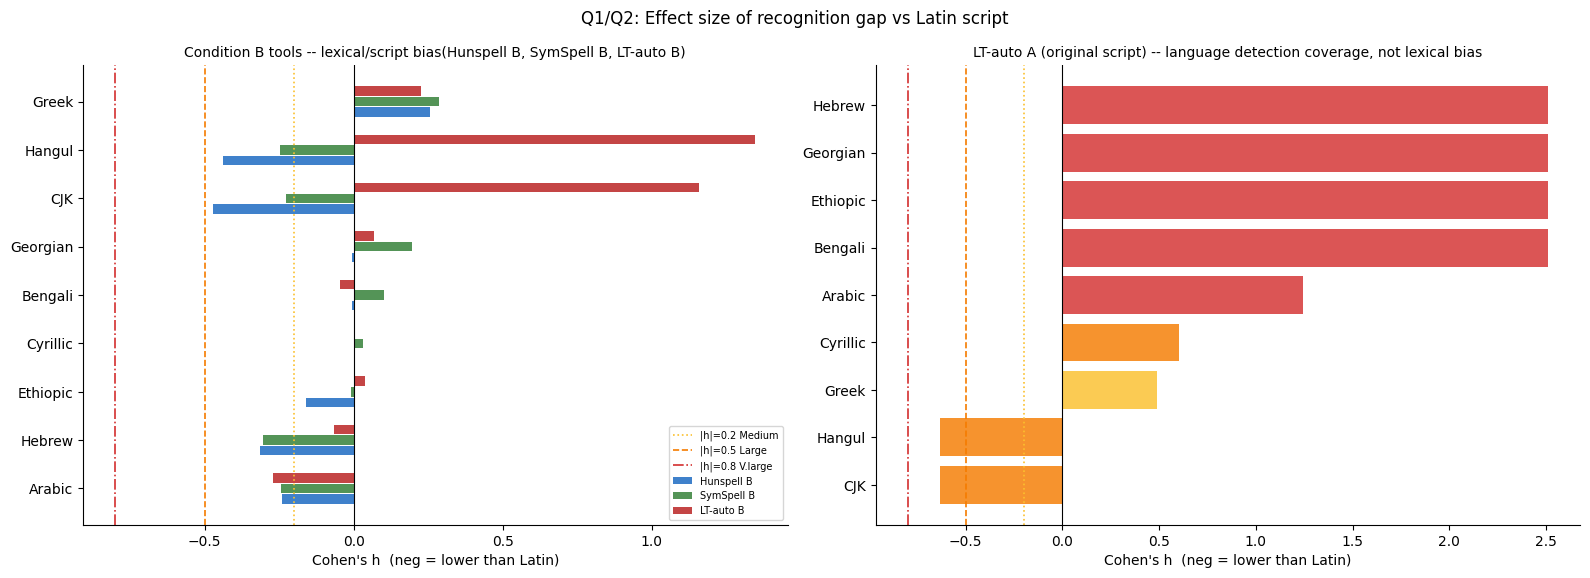

Chart 1: consistent negative h across all three Condition B tools = systemic lexical/script bias.
Chart 2: LT-auto A differs sharply -- Arabic, Hebrew, etc. high because language detection works;
  CJK/Hangul near-zero because it does not. Different mechanism, should not be conflated.


In [13]:
# Q1: Cohen's h -- split by interpretive meaning.
#
# Chart 1 (COND_B): Hunspell B, SymSpell B, LT-auto B -- all operating on Latin
# transliterations. Pattern here reflects lexical/script bias in the dictionary.
#
# Chart 2 (LT-auto A only): Original-script run. Arabic/Hebrew are recognised
# in A because LT-auto's language detection picks them up -- NOT because the
# dictionary knows the names. CJK/Hangul are near-zero because detection fails.
# This is a language-detection capability gap, not the same bias as Chart 1.

# ── Chart 1: COND_B ──────────────────────────────────────────────────────────
h_data = {}
for col, label in COND_B:
    tbl = cohens_h_table(df_major, "name_script", col, "Latin")
    h_data[label] = tbl[tbl["group"] != "Latin"].set_index("group")["Cohen_h"]

h_df = pd.DataFrame(h_data).dropna(how="all")
h_df = h_df.loc[h_df.mean(axis=1).sort_values().index]

n_s = len(h_df)
bar_h = 0.22
y = np.arange(n_s)
offsets = np.linspace(-1, 1, 3) * bar_h
bar_colors = ["#1565c0", "#2e7d32", "#b71c1c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(5, n_s * 0.65)))

for label, offset, color in zip(h_df.columns, offsets, bar_colors):
    ax1.barh(y + offset, h_df[label], height=bar_h*0.9,
             label=label, color=color, alpha=0.82)

for xval, lbl, ls, col in [
    (-0.20, "Medium",   ":" , "#fbc02d"),
    (-0.50, "Large",    "--", "#f57c00"),
    (-0.80, "V.large",  "-.", "#d32f2f"),
]:
    ax1.axvline(xval, color=col, linestyle=ls, linewidth=1.2, label=f"|h|={abs(xval)} {lbl}")

ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_yticks(y); ax1.set_yticklabels(h_df.index)
ax1.set_xlabel("Cohen's h  (neg = lower than Latin)")
ax1.set_title("Condition B tools -- lexical/script bias(Hunspell B, SymSpell B, LT-auto B)", fontsize=10)
ax1.legend(fontsize=7, loc="lower right")
for s in ["top","right"]: ax1.spines[s].set_visible(False)

# ── Chart 2: LT-auto A only ──────────────────────────────────────────────────
lt_tbl = cohens_h_table(df_major, "name_script", LT_ORIG_COL, "Latin")
lt_tbl = lt_tbl[lt_tbl["group"] != "Latin"].sort_values("Cohen_h")

lt_colors = ["#d32f2f" if abs(h) > 0.80
             else "#f57c00" if abs(h) > 0.50
             else "#fbc02d" if abs(h) > 0.20
             else "#81c784" for h in lt_tbl["Cohen_h"]]

ax2.barh(lt_tbl["group"], lt_tbl["Cohen_h"], color=lt_colors, alpha=0.82)
ax2.axvline(0, color="black", linewidth=0.8)
for xval, ls, col in [(-0.20,":","#fbc02d"),(-0.50,"--","#f57c00"),(-0.80,"-.","#d32f2f")]:
    ax2.axvline(xval, color=col, linestyle=ls, linewidth=1.2)
ax2.set_xlabel("Cohen's h  (neg = lower than Latin)")
ax2.set_title("LT-auto A (original script) -- language detection coverage, not lexical bias", fontsize=10)
for s in ["top","right"]: ax2.spines[s].set_visible(False)

fig.suptitle("Q1/Q2: Effect size of recognition gap vs Latin script", fontsize=12)
plt.tight_layout()
plt.show()

print("Chart 1: consistent negative h across all three Condition B tools = systemic lexical/script bias.")
print("Chart 2: LT-auto A differs sharply -- Arabic, Hebrew, etc. high because language detection works;")
print("  CJK/Hangul near-zero because it does not. Different mechanism, should not be conflated.")


---
## Q1/Q2: Language Origin Analysis

Two language signals are available for every name:

- **** -- primary official language of the predicted country of origin
- **** -- language detected from the name's character patterns
- **** -- whether the two agree (the name "looks like" what you'd expect from its country)

High-agreement names (e.g. Pierre: France, French) are prototypical for their origin.
Low-agreement names (e.g. a Yoruba name from Nigeria, which has English as official language) are
from post-colonial or multilingual contexts -- their phonetic patterns deviate from the
official-language norm, even though that country is technically English-speaking.

The key question: is recognition driven by the official linguistic context of a name's origin,
or by what the name actually looks like? If spell-checkers fail names where the two disagree,
that's evidence the tools are optimised for Western orthographic patterns rather than the
full linguistic reality of a country.


Q1: Recognition rates by primary official language -- Condition B, Latin-script names
-- Hunspell B --
group     n  known  rate_%  CI_low  CI_high  CI_width
   fr 20949   2214 10.5700 10.1600  10.9900    0.8330
   en 86909   6707  7.7200  7.5400   7.9000    0.3550
   de  8313    634  7.6300  7.0800   8.2200    1.1420
   nl  6523    440  6.7500  6.1600   7.3800    1.2180
   af 20616   1369  6.6400  6.3100   6.9900    0.6800
   it 15307    992  6.4800  6.1000   6.8800    0.7800
   ar 75911   4668  6.1500  5.9800   6.3200    0.3420
   es 46939   2376  5.0600  4.8700   5.2600    0.3970
   cs  5683    219  3.8500  3.3800   4.3900    1.0020
   hu  8135    298  3.6600  3.2800   4.0900    0.8170
   pt 17831    633  3.5500  3.2900   3.8300    0.5440
   tr 11713    366  3.1200  2.8200   3.4600    0.6310
   hi  9604    208  2.1700  1.8900   2.4800    0.5830
   lt  7326     91  1.2400  1.0100   1.5200    0.5100
   sq  6766     82  1.2100  0.9800   1.5000    0.5240

-- SymSpell B --
group     n  kn

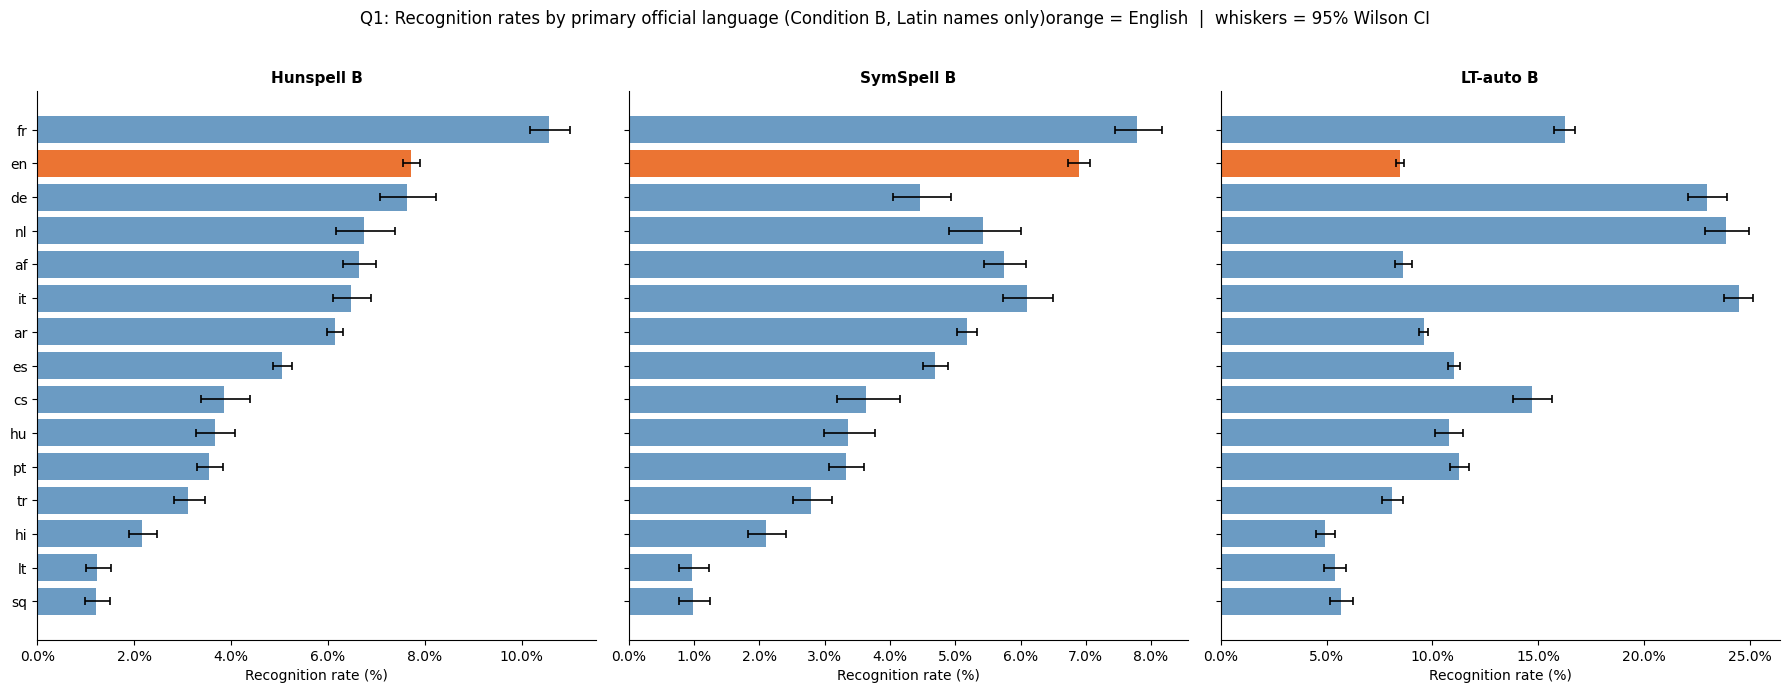

Languages far below English = limited lexical coverage in the English dictionary.
LT-auto B higher for European languages (Spanish, Portuguese, Italian) -- language-specific dictionaries.


In [14]:
# Q1: Recognition rates by primary official language (top_country_langs[0])
# Latin-script names only -- isolates lexical bias from script.

import json as _json

def get_primary_lang(val):
    if not isinstance(val, str) or val == '': return None
    try:
        langs = _json.loads(val)
        return langs[0] if langs else None
    except Exception: return None

df['primary_lang'] = df['top_country_langs'].apply(get_primary_lang)
lat = df_latin_only.copy()
lat['primary_lang'] = df.loc[df_latin_only.index, 'primary_lang']

top_langs = lat['primary_lang'].value_counts().head(15).index.tolist()

print('Q1: Recognition rates by primary official language -- Condition B, Latin-script names')
for col, label in COND_B:
    tbl = recognition_table(lat[lat['primary_lang'].isin(top_langs)], 'primary_lang', col)
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()

lang_sub = lat[lat['primary_lang'].isin(top_langs)]
ref_lang_order = (
    recognition_table(lang_sub, 'primary_lang', 'hunspell_latin_known')
    .sort_values('rate_%', ascending=True)['group'].tolist()
)

fig, axes = plt.subplots(1, 3,
                          figsize=(18, max(5, len(ref_lang_order)*0.45)),
                          sharey=True)

for ax, (col, label) in zip(axes, COND_B):
    tbl = (
        recognition_table(lang_sub, 'primary_lang', col)
        .set_index('group').reindex(ref_lang_order).reset_index()
    )
    colors = ['#e65100' if g == 'en' else 'steelblue' for g in tbl['group']]
    ax.barh(
        tbl['group'], tbl['rate_%'],
        xerr=[tbl['rate_%'] - tbl['CI_low'], tbl['CI_high'] - tbl['rate_%']],
        color=colors, alpha=0.80, capsize=3,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2},
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Recognition rate (%)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

fig.suptitle(
    'Q1: Recognition rates by primary official language (Condition B, Latin names only)'
    'orange = English  |  whiskers = 95% Wilson CI',
    fontsize=12, y=1.02
)
plt.tight_layout(); plt.show()

print('Languages far below English = limited lexical coverage in the English dictionary.')
print('LT-auto B higher for European languages (Spanish, Portuguese, Italian) -- language-specific dictionaries.')


Recognition rates by country_lang_comp -- Condition B
All scripts:
 condition                group      n  rate_%  CI_low  CI_high
Hunspell B Matches country lang  98402  5.0100  4.8800   5.1500
Hunspell B       Does not match 472626  4.8800  4.8200   4.9400
SymSpell B Matches country lang  98402  4.3700  4.2500   4.5000
SymSpell B       Does not match 472626  4.1100  4.0600   4.1700
 LT-auto B Matches country lang  98402 22.3900 22.1300  22.6600
 LT-auto B       Does not match 472626 11.3800 11.2900  11.4700
Latin-script names only (script not a confounder):
 condition                group      n  rate_%  CI_low  CI_high
Hunspell B Matches country lang  48241  7.7900  7.5600   8.0400
Hunspell B       Does not match 415213  5.1600  5.0900   5.2300
SymSpell B Matches country lang  48241  6.4900  6.2700   6.7100
SymSpell B       Does not match 415213  4.2400  4.1800   4.3000
 LT-auto B Matches country lang  48241 22.7200 22.3400  23.0900
 LT-auto B       Does not match 415213  9.0500  8.

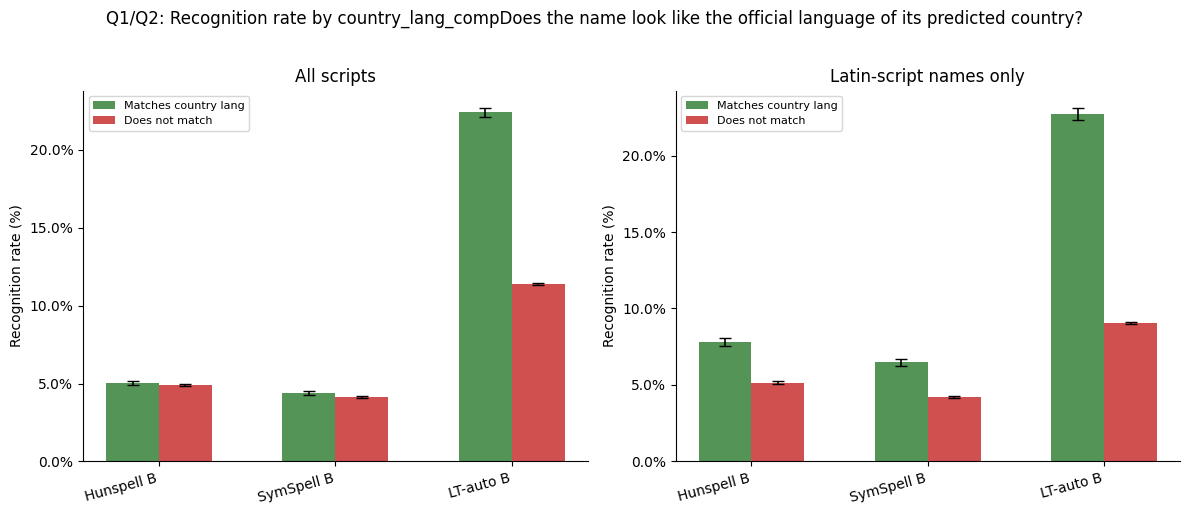

If the gap persists in the Latin-only panel, it is lexical/phonological,
not a script effect -- the tools penalise names that deviate from Western
orthographic norms even when they share the same alphabet.


In [15]:
# Q1/Q2: Does the name look like the official language of its predicted country?
# country_lang_comp = True  : detected language matches a country official language
# country_lang_comp = False : does not match (post-colonial / diaspora / multilingual)
#
# Argument: if False-names are consistently less recognised even within Latin script,
# the tools reward phonetic conformity to Western orthographic norms.

# Pre-cast once -- avoids slow per-row Python bool comparison on 571k rows
comp_flag = df["country_lang_comp"].astype(bool)
comp_flag_lat = df_latin_only["country_lang_comp"].astype(bool)

group_labels = {True: "Matches country lang", False: "Does not match"}

# ── Tables ───────────────────────────────────────────────────────────────────
print("Recognition rates by country_lang_comp -- Condition B")

print("All scripts:")
rows = []
for col, label in COND_B:
    for flag in (True, False):
        sub = df[comp_flag == flag]
        n = len(sub); k = int(sub[col].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
        rows.append({"condition": label, "group": group_labels[flag],
                     "n": n, "rate_%": round(k/n*100, 2),
                     "CI_low": round(lo*100, 2), "CI_high": round(hi*100, 2)})
print(pd.DataFrame(rows).to_string(index=False))

print("Latin-script names only (script not a confounder):")
lat_rows = []
for col, label in COND_B:
    for flag in (True, False):
        sub = df_latin_only[comp_flag_lat == flag]
        n = len(sub); k = int(sub[col].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
        lat_rows.append({"condition": label, "group": group_labels[flag],
                         "n": n, "rate_%": round(k/n*100, 2),
                         "CI_low": round(lo*100, 2), "CI_high": round(hi*100, 2)})
print(pd.DataFrame(lat_rows).to_string(index=False))

# ── Chart ────────────────────────────────────────────────────────────────────
# Two panels: all scripts (left) and Latin only (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, row_src, title in [
    (ax1, pd.DataFrame(rows),     "All scripts"),
    (ax2, pd.DataFrame(lat_rows), "Latin-script names only"),
]:
    cond_lbls = row_src["condition"].unique()
    x = np.arange(len(cond_lbls))
    w = 0.30
    for i, (flag, gname, color) in enumerate([
        (True,  "Matches country lang", "#2e7d32"),
        (False, "Does not match",        "#c62828"),
    ]):
        grp = row_src[row_src["group"] == gname]
        vals = grp["rate_%"].values
        err_lo = (grp["rate_%"] - grp["CI_low"]).values
        err_hi = (grp["CI_high"] - grp["rate_%"]).values
        ax.bar(x + i*w, vals, w, label=gname, color=color, alpha=0.82,
               yerr=[err_lo, err_hi], capsize=4,
               error_kw={"elinewidth": 1.2})
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(cond_lbls, rotation=15, ha="right")
    ax.set_ylabel("Recognition rate (%)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(title)
    ax.legend(fontsize=8)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

fig.suptitle(
    "Q1/Q2: Recognition rate by country_lang_comp"
    "Does the name look like the official language of its predicted country?",
    y=1.02
)
plt.tight_layout()
plt.show()

print("If the gap persists in the Latin-only panel, it is lexical/phonological,")
print("not a script effect -- the tools penalise names that deviate from Western")
print("orthographic norms even when they share the same alphabet.")


---
## Q2 (continued): Logistic Regression

Regression estimates the effect of name origin *controlling for* name length and
origin-confidence score (). If the group effect survives controls,
the bias argument is stronger.

**Script model:** Latin = reference. OR < 1.0 means lower odds than Latin-script names.
**Origin model:** British = reference, Latin-script names only. Any OR < 1.0 here is lexical,
not script-related.

Runtime: ~2-5 min per model at this n.


In [16]:
# Q2: Logistic regression by script, one model per condition
# Latin is the reference category.
#
# Note: LT-auto A has near-zero recognition for CJK and Hangul (language detection
# cannot help those scripts), causing perfect separation for those categories.
# The Newton-Raphson solver fails with a singular Hessian in that case.
# We fall back to BFGS, which handles separation more gracefully.

def logreg_script(data, outcome_col, cond_label):
    print(f'{"="*60}')
    print(f'Condition: {cond_label}  |  outcome: {outcome_col}')
    print(f'Predictors: script (ref=Latin), top_country_prob, name_length')
    print(f'{"="*60}')

    reg = data.copy()
    order = ['Latin'] + [s for s in MAJOR_SCRIPTS if s != 'Latin']
    reg['script_cat'] = pd.Categorical(reg['name_script'], categories=order)
    reg[outcome_col]  = reg[outcome_col].astype(int)

    formula = f'{outcome_col} ~ C(script_cat) + top_country_prob + name_length'

    # Try Newton (default, faster); fall back to BFGS if Hessian is singular.
    # Singular Hessian occurs when a category has near-zero or near-100% recognition
    # (perfect separation), as happens for CJK/Hangul under LT-auto A.
    try:
        model = smf.logit(formula, data=reg).fit(maxiter=200, disp=False)
        solver_used = 'newton'
    except np.linalg.LinAlgError:
        print('  [Newton failed -- falling back to BFGS (handles perfect separation)]')
        model = smf.logit(formula, data=reg).fit(
            method='bfgs', maxiter=500, disp=False
        )
        solver_used = 'bfgs'

    params = model.params
    ci     = model.conf_int()
    or_df  = pd.DataFrame({
        'OR':      np.exp(params).round(4),
        'CI_low':  np.exp(ci.iloc[:, 0]).round(4),
        'CI_high': np.exp(ci.iloc[:, 1]).round(4),
        'p':       model.pvalues,
    })
    or_df['sig'] = or_df['p'].apply(
        lambda v: '***' if v < 0.001 else ('**' if v < 0.01 else ('*' if v < 0.05 else 'ns'))
    )
    or_df['p'] = or_df['p'].apply(lambda v: f'{v:.2e}')
    or_df.index = (
        or_df.index
        .str.replace(r'C\(script_cat\)\[T\.', '', regex=True)
        .str.replace(']', '', regex=False)
    )

    print(f'Solver: {solver_used}')
    print(f'Pseudo R2 (McFadden): {1 - model.llf / model.llnull:.4f}')
    print(f'n = {len(reg):,}')
    print(or_df.to_string())
    print('OR < 1.0 = lower odds of recognition vs Latin.')
    print('OR ~ 0 for a script = near-complete barrier (e.g. CJK under LT-auto A).')


for col, label in FOCUS_CONDS:
    logreg_script(df_major, col, label)


Condition: Hunspell B  |  outcome: hunspell_latin_known
Predictors: script (ref=Latin), top_country_prob, name_length
Solver: newton
Pseudo R2 (McFadden): 0.0696
n = 567,985
                     OR  CI_low  CI_high          p  sig
Intercept        0.6235  0.5938   0.6546   1.70e-80  ***
Arabic           0.1687  0.1530   0.1859  2.65e-281  ***
Cyrillic         1.2467  1.1783   1.3190   1.81e-14  ***
CJK              0.0000  0.0000      inf   1.00e+00   ns
Hangul           0.0019  0.0006   0.0058   1.44e-27  ***
Hebrew           0.0711  0.0483   0.1046   5.03e-41  ***
Bengali          0.7363  0.6231   0.8699   3.21e-04  ***
Greek            3.6085  3.2388   4.0203  8.32e-120  ***
Georgian         0.9664  0.7964   1.1728   7.29e-01   ns
Ethiopic         0.2229  0.1355   0.3668   3.45e-09  ***
top_country_prob 0.3072  0.2923   0.3228   0.00e+00  ***
name_length      0.7588  0.7527   0.7649   0.00e+00  ***
OR < 1.0 = lower odds of recognition vs Latin.
OR ~ 0 for a script = near-complete ba

In [17]:
# Q2: Logistic regression by origin category -- Condition B, Latin-script names only.
# British is the reference category.
# Any OR < 1.0 here cannot be explained by script -- it is lexical bias.

def logreg_ethnicity(data, outcome_col, cond_label):
    print(f'\n{"="*60}')
    print(f'Condition: {cond_label}  |  outcome: {outcome_col}')
    print(f'Predictors: origin category (ref=British), top_country_prob, name_length')
    print(f'LATIN-SCRIPT NAMES ONLY')
    print(f'{"="*60}')

    reg = data[data['eth_short'] != 'Unknown'].copy()
    counts = reg['eth_short'].value_counts()
    reg    = reg[reg['eth_short'].isin(counts[counts >= 100].index)].copy()

    eth_order     = ['British'] + [e for e in reg['eth_short'].unique() if e != 'British']
    reg['eth_cat']   = pd.Categorical(reg['eth_short'], categories=eth_order)
    reg[outcome_col] = reg[outcome_col].astype(int)

    model = smf.logit(
        f'{outcome_col} ~ C(eth_cat) + top_country_prob + name_length',
        data=reg
    ).fit(maxiter=200, disp=False)

    params = model.params
    ci     = model.conf_int()
    or_df  = pd.DataFrame({
        'OR':      np.exp(params).round(4),
        'CI_low':  np.exp(ci.iloc[:, 0]).round(4),
        'CI_high': np.exp(ci.iloc[:, 1]).round(4),
        'p':       model.pvalues,
    })
    or_df['sig'] = or_df['p'].apply(
        lambda v: '***' if v < 0.001 else ('**' if v < 0.01 else ('*' if v < 0.05 else 'ns'))
    )
    or_df['p'] = or_df['p'].apply(lambda v: f'{v:.2e}')
    or_df.index = (
        or_df.index
        .str.replace(r'C\(eth_cat\)\[T\.', '', regex=True)
        .str.replace(']', '', regex=False)
    )

    print(f'Pseudo R2 (McFadden): {1 - model.llf / model.llnull:.4f}')
    print(f'n = {len(reg):,}\n')
    print(or_df.to_string())
    print('\nOR < 1.0 = lower odds of recognition vs British (lexical bias, not script).')


for col, label in COND_B:
    logreg_ethnicity(df_latin_only, col, label)



Condition: Hunspell B  |  outcome: hunspell_latin_known
Predictors: origin category (ref=British), top_country_prob, name_length
LATIN-SCRIPT NAMES ONLY
Pseudo R2 (McFadden): 0.0669
n = 463,454

                       OR  CI_low  CI_high          p  sig
Intercept          0.8914  0.8391   0.9469   1.91e-04  ***
Muslim             0.3516  0.3304   0.3743  2.39e-236  ***
EastAsian          0.5399  0.5201   0.5605  9.58e-229  ***
Italian            0.7459  0.6983   0.7967   2.92e-18  ***
Germanic           0.8038  0.7454   0.8667   1.36e-08  ***
EastEuropean       0.6426  0.5947   0.6944   5.28e-29  ***
Africans           0.1541  0.1357   0.1750  4.60e-182  ***
Japanese           0.3174  0.2945   0.3420  1.08e-198  ***
Nordic             0.7856  0.7528   0.8198   1.17e-28  ***
IndianSubContinent 0.2687  0.2541   0.2842   0.00e+00  ***
Jewish             0.3764  0.3439   0.4120  9.52e-100  ***
French             1.9617  1.7914   2.1482   6.44e-48  ***
Hispanic           0.7226  0.6716   0

---
## Q3: Correction Behaviour

When a name is flagged, what does the spell-checker suggest? Each correction is
passed through ethnicolr to predict its likely origin. For each source-origin group:

- **pct_Western_%** -- share of corrections predicted as Western-adjacent
- **pct_same_origin_%** -- share staying within the same origin category
- **top_3_correction_origins** -- most common correction origins

If non-Western names consistently receive Western suggestions at higher rates than
Western names do, that's a correction skew -- the tool is not just failing to recognise
the name, it's actively pushing toward Westernised alternatives.


In [18]:
# Parse correction_match JSON fields
def extract_corr_race(val):
    """Extract ethnicolr_race from the correction_match JSON string."""
    if not isinstance(val, str) or val == '':
        return None
    try:
        return json.loads(val).get('ethnicolr_race')
    except (json.JSONDecodeError, AttributeError):
        return None


CORR_COLS = [
    ('hunspell_latin_correction_match', 'Hunspell'),
    ('symspell_latin_correction_match', 'SymSpell'),
    ('lt_auto_latin_correction_match',  'LT-auto'),
]

for col, label in CORR_COLS:
    race_col  = f'{label}_corr_race'
    eth_col   = f'{label}_corr_eth'
    df[race_col] = df[col].apply(extract_corr_race)
    df[eth_col]  = df[race_col].str.split(',').str[-1].fillna('None')

print('Names with a matched correction (Condition B):')
for col, label in CORR_COLS:
    n = (df[f'{label}_corr_eth'] != 'None').sum()
    print(f'  {label}: {n:,}')

Names with a matched correction (Condition B):
  Hunspell: 237,061
  SymSpell: 289,612
  LT-auto: 197,875


In [19]:
# For each tool: group names by source origin, show where corrections point
print('Correction direction -- Condition B (Latin transliteration)')
print('For each source-origin group, what fraction of corrections point to Western names?')
print('Western = British + Germanic + Nordic + French + Italian\n')

for col, label in CORR_COLS:
    eth_col  = f'{label}_corr_eth'
    has_corr = df[(df[eth_col] != 'None') & (df['eth_short'] != 'Unknown')].copy()

    if has_corr.empty:
        print(f'{label}: no corrections found.\n')
        continue

    rows = []
    for src, grp in has_corr.groupby('eth_short'):
        if len(grp) < 20:
            continue
        n_total  = len(grp)
        n_west   = grp[eth_col].isin(WESTERN_ETH).sum()
        n_same   = (grp[eth_col] == src).sum()
        top3     = grp[eth_col].value_counts().head(3)
        rows.append({
            'source_origin':        src,
            'n_corrections':        n_total,
            'pct_Western_%':        round(n_west / n_total * 100, 1),
            'pct_same_origin_%':    round(n_same / n_total * 100, 1),
            'top_3_correction_origins': ', '.join(f'{k}({v})' for k, v in top3.items()),
        })

    if rows:
        tbl = pd.DataFrame(rows).sort_values('pct_Western_%', ascending=False)
        print(f'-- {label} --')
        print(tbl.to_string(index=False))
        print()

print('pct_Western_% > 50 means more than half of corrections point to Western-origin names.')
print('Compare Western-origin rows (e.g. British) to non-Western rows to gauge the skew.')

Correction direction -- Condition B (Latin transliteration)
For each source-origin group, what fraction of corrections point to Western names?
Western = British + Germanic + Nordic + French + Italian

-- Hunspell --
     source_origin  n_corrections  pct_Western_%  pct_same_origin_%                                  top_3_correction_origins
           British          38247        64.7000            47.1000             British(18009), EastAsian(7131), Nordic(4292)
            Nordic          25487        62.6000            37.0000              Nordic(9438), British(4527), EastAsian(4467)
            French           1938        61.2000            17.4000                 British(511), French(338), EastAsian(322)
           Italian           8501        61.2000            30.0000             Italian(2547), British(1421), EastAsian(1187)
          Germanic           6392        55.9000            22.1000             Germanic(1412), EastAsian(1209), British(974)
          Hispanic          

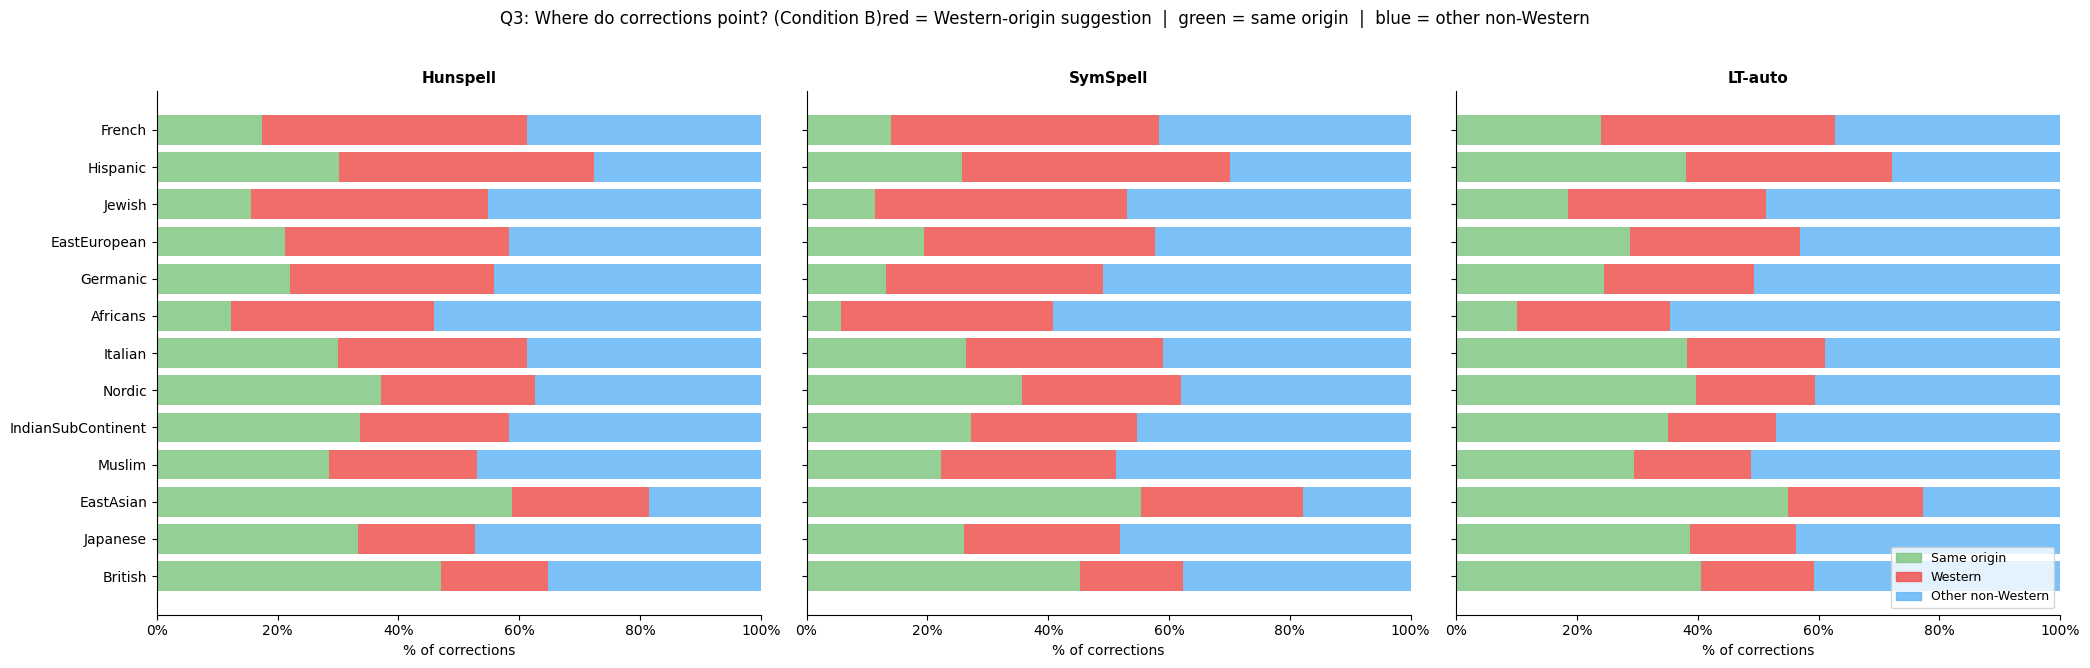

Western bar larger for non-Western source groups than Western ones = correction skew.
Consistent across all three panels = systemic, not tool-specific.


In [20]:
# Q3: Correction direction -- 3-panel stacked bar, one panel per tool.
# All tools side-by-side shows whether correction skew is systemic or tool-specific.

cmap_dir = {"Same origin": "#81c784", "Western": "#ef5350", "Other non-Western": "#64b5f6"}
dir_order = ["Same origin", "Western", "Other non-Western"]

def get_direction(row, eth_col):
    c, s = row[eth_col], row["eth_short"]
    if c == s: return "Same origin"
    return "Western" if c in WESTERN_ETH else "Other non-Western"

# Shared y-axis order from first tool
first_ecol = f"{CORR_COLS[0][1]}_corr_eth"
first_df = df[(df[first_ecol] != "None") & (df["eth_short"] != "Unknown")].copy()
first_df["direction"] = first_df.apply(lambda r: get_direction(r, first_ecol), axis=1)
first_pivot = first_df.groupby(["eth_short", "direction"]).size().unstack(fill_value=0)
first_pct  = first_pivot.div(first_pivot.sum(axis=1), axis=0) * 100
shared_order = (
    first_pct["Western"].sort_values(ascending=True).index.tolist()
    if "Western" in first_pct.columns else first_pct.index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(21, max(5, len(shared_order) * 0.5)), sharey=True)

for ax, (corr_col, label) in zip(axes, CORR_COLS):
    ecol     = f"{label}_corr_eth"
    has_corr = df[(df[ecol] != "None") & (df["eth_short"] != "Unknown")].copy()
    if has_corr.empty:
        ax.set_title(f"{label} (no corrections found)")
        continue
    has_corr["direction"] = has_corr.apply(lambda r: get_direction(r, ecol), axis=1)
    pivot     = has_corr.groupby(["eth_short", "direction"]).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct = pivot_pct.reindex(shared_order).dropna(how="all")
    present   = [d for d in dir_order if d in pivot_pct.columns]
    left = np.zeros(len(pivot_pct))
    for cat in present:
        vals = pivot_pct[cat].fillna(0).values
        ax.barh(pivot_pct.index, vals, left=left, color=cmap_dir[cat], alpha=0.85)
        left += vals
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("% of corrections")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 100)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

handles = [plt.Rectangle((0,0),1,1,color=cmap_dir[d],alpha=0.85) for d in dir_order]
axes[-1].legend(handles, dir_order, loc="lower right", fontsize=9)

fig.suptitle(
    "Q3: Where do corrections point? (Condition B)"
    "red = Western-origin suggestion  |  green = same origin  |  blue = other non-Western",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print("Western bar larger for non-Western source groups than Western ones = correction skew.")
print("Consistent across all three panels = systemic, not tool-specific.")


---
## Summary

| Claim | Evidence | Strength |
|-------|----------|----------|
| Recognition gap exists (Q1) | Wilson CIs + chi-sq + Cohen's h | Very strong |
| Gap is consistent across tools (Q1) | All three tools show same direction | Strong |
| Gap is partly script-level (Q2) | McNemar (LT-auto A vs B) + logreg script model | Strong |
| Gap has lexical component (Q2) | Logreg origin model, Latin-script only | Moderate |
| Phonetic conformity drives recognition (Q2) | country_lang_comp + primary lang analysis | Moderate |
| Corrections skew Western (Q3) | Direction analysis | Exploratory |

**country_lang_comp** is a useful additional lens: names from countries where the
detected language doesn't match the official language are recognised less even within
Latin script -- the tools reward phonetic conformity to Western orthographic norms.
